## Notebook Setup

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
import os
import json
import joblib
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from numpy import float64
from sklearn.metrics import roc_auc_score
from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed
# from interpret.glassbox import ExplainableBoostingClassifier
from utils.model_loaders import load_logistic_models_for_subfolder



set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

INFO 03-23 11:11:27 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform


In [2]:
## Load best param


best_params = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    results = json.load(open(f"best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "judge" in f:
        best_params["judge"].append(_params)
    else:
        best_params["groundtruth"].append(_params)

In [3]:
def _get_split_sets(df, subfolder, split):
    split_df = df.filter((pl.col("subfolder") == subfolder) & (pl.col("split") == split))

    X_split = []
    y_split = []

    for exp in EXPERIMENTS:
        exp_df = split_df.filter(pl.col("experiment") == exp)

        X_exp = exp_df.select("input").to_numpy()
        X_exp = np.array([i[0] for i in X_exp])
        y_exp = exp_df.select("evaluation").to_numpy()

        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        num_arrays = 500

        X_exp_reshaped = []
        y_exp_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_exp_reshaped.append(X_exp[i::num_arrays])
            y_exp_reshaped.append(y_exp[i::num_arrays])

        X_split.append(X_exp_reshaped)
        y_split.append(y_exp_reshaped)

    return X_split, y_split


def get_train_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="train")


def get_test_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="test")

In [4]:
df = []

for subfolder in ["voting"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Could not load voting/experiment_73/train: No such file or directory (os error 2): binary_collections/voting/experiment_73/train.feather
Could not load voting/experiment_73/test: No such file or directory (os error 2): binary_collections/voting/experiment_73/test.feather


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 32]",i32,str,str,str
0,0,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,1,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,2,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,3,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""
0,4,"[0, 0, … 1]",0,"""voting""","""experiment_1""","""train"""


## Logistic Regression - Variation of Instructions in Binary Collections

In this ssection we will analyse the judge for the following prompt workin with a consensus of at least two same results:

```
 [System] 
    Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to a question displayed below. Begin your evaluation by providing a short explanation. Be as objective as possible. After providing your explanation, please classify the response as 1 for RESPONDS QUESTION and 0 for NOT RESPONDES QUESTION by strictly following this format: "[[classification]]", for example: "Classification: [[1]]".  
    [Question] 
    {question}  
    [The Start of Assistant’s Answer] 
    {response}
    [The End of Assistant’s Answer]



### Distribution Analysis

In [5]:
alt1_train = df.filter((pl.col("subfolder") == "voting") & (pl.col("split") == "train"))
alt1_test = df.filter((pl.col("subfolder") == "voting") & (pl.col("split") == "test"))


In [8]:
alt1_train["evaluation"].unique()

evaluation
i32
0


ZeroDivisionError: division by zero

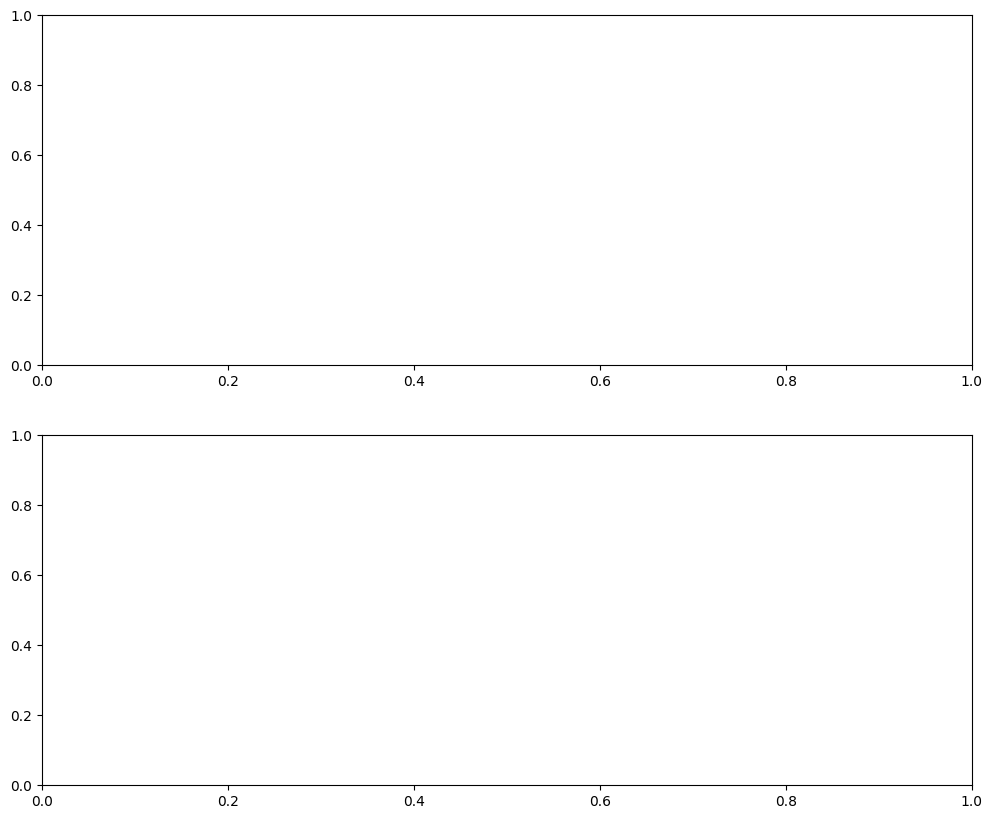

In [6]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
train_data = []
for exp in EXPERIMENTS:
    _exp = alt1_train.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    train_data.append({"experiment": exp, "percentage": pct})
train_df = pl.DataFrame(train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Judge Alt1 - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
test_data = []
for exp in EXPERIMENTS:
    _exp = alt1_test.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    test_data.append({"experiment": exp, "percentage": pct})
test_df = pl.DataFrame(test_data)

# Plot test data
sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Judge Alt1 - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training Models

In [ ]:
X_alt1_train, y_alt1_train = get_train_sets(df, "voting")
alt1_models = []



with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _alt1_arr = []
        for j in range(500):
            # Alt1 model
            X_alt1 = X_alt1_train[i][j]
            y_alt1 = y_alt1_train[i][j].ravel()
            
            if best_params["judge"][i][j] is None:
                _alt1_arr.append(None)
            else:
                model_alt1 = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_alt1.fit(X_alt1, y_alt1)
                _alt1_arr.append(model_alt1)
           
            


            
            pbar.update(1)
        
        alt1_models.append(_alt1_arr)

del X_alt1_train, y_alt1_train

Training models: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [04:10<00:00,  9.97it/s]


In [15]:
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    alt1_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt1/"
    alt2_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt2/"
    os.makedirs(alt2_path, exist_ok=True)
    os.makedirs(alt1_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_bias.pt")

/tmp/ipykernel_1013027/537923468.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
/tmp/ipykernel_1013027/537923468.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")
/tmp/ipykernel_1013027/537923468.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensu

In [11]:
LOAD = True
if LOAD:
    alt1_models = load_logistic_models_for_subfolder("judge", "alt1_weights.pt", "alt1_bias.pt", experiments=EXPERIMENTS)
    alt2_models = load_logistic_models_for_subfolder("judge", "alt2_weights.pt", "alt2_bias.pt", experiments=EXPERIMENTS)

In [13]:
X_alt1_test, y_alt1_test = get_test_sets(df, "alt1")
X_alt2_test, y_alt2_test = get_test_sets(df, "alt2")


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        alt1_lr = alt1_models[i][j]
        if alt1_lr is not None:

            _x = X_alt1_test[i][j]
            _y = y_alt1_test[i][j].ravel()
            score = roc_auc_score(_y, alt1_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("alt1")
            _eval_df["auc"].append(score)

        alt2_lr = alt2_models[i][j]
        if alt2_lr is not None:
            _x = X_alt2_test[i][j]
            _y = y_alt2_test[i][j].ravel()
            score = roc_auc_score(_y, alt2_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("alt2")
            _eval_df["auc"].append(score)



del X_alt1_test, y_alt1_test, X_alt2_test, y_alt2_test
gc.collect()

511

In [15]:
eval_df = pl.DataFrame(_eval_df)    
eval_df.filter(pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean().alias("mean_auc"), pl.col("auc").std().alias("std_auc"))

type,mean_auc,std_auc
str,f64,f64
"""alt2""",0.555232,0.06655
"""alt1""",0.590805,0.082759


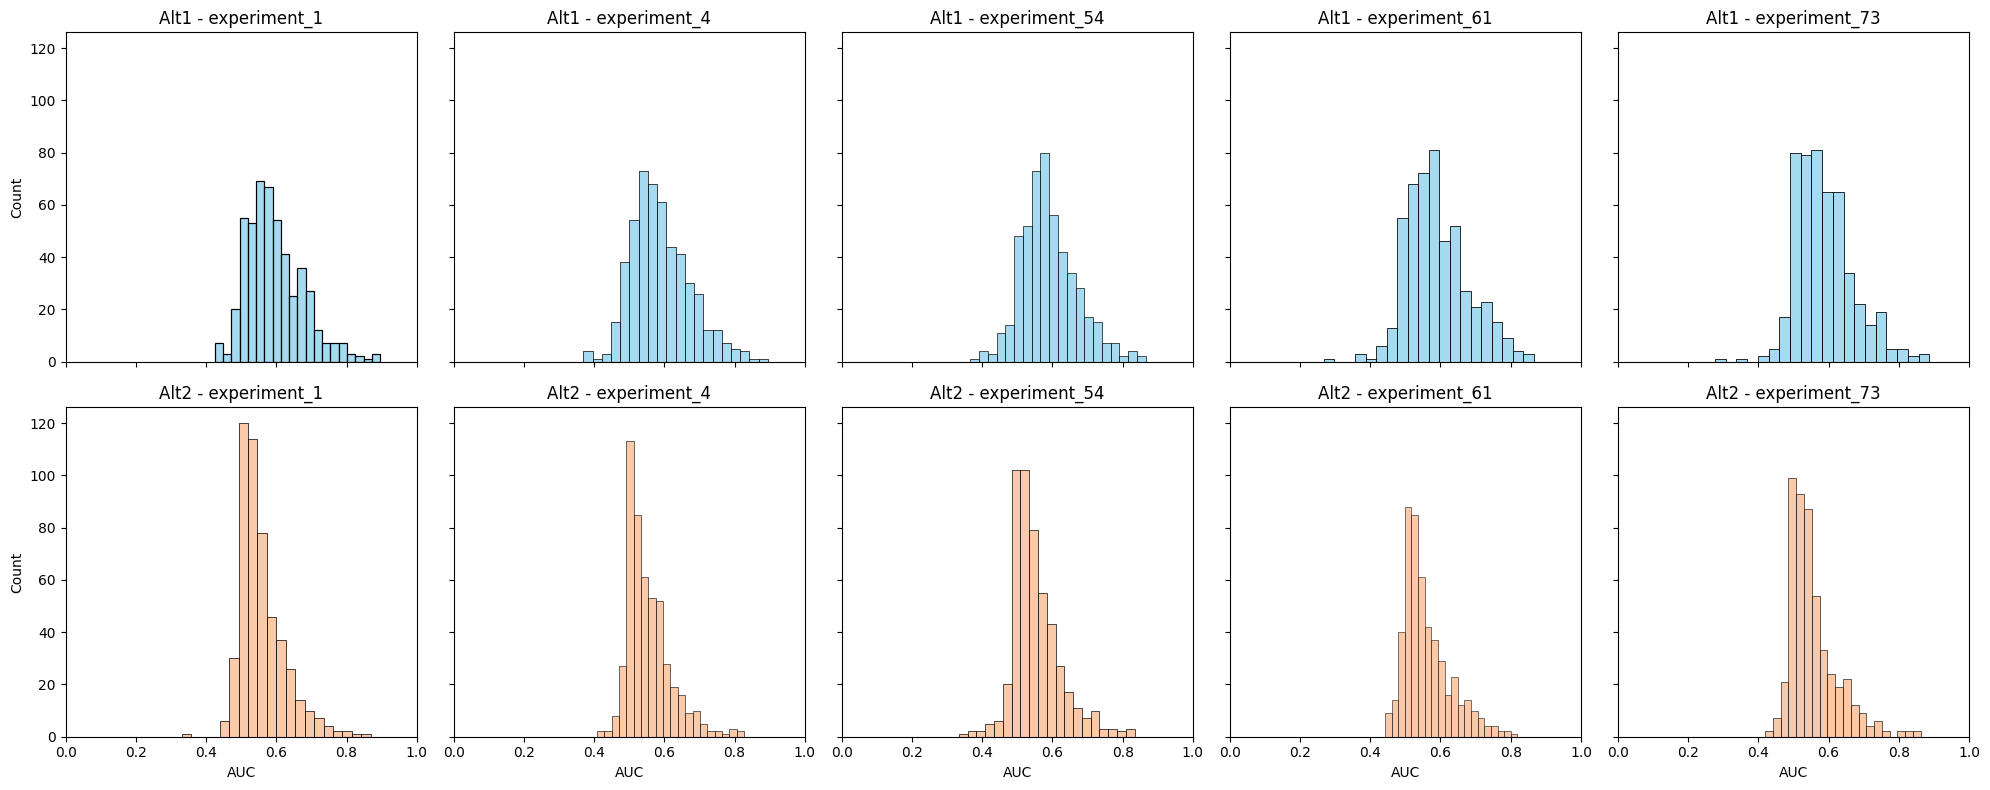

In [17]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)    
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"alt1": "#87CEEB", "alt2": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["alt1", "alt2"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

### Text Generation Results

In [16]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = True
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "alt" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/alternative_inputs.feather")
else:
    generations_results = pl.read_ipc("generation_results/alternative_inputs.feather")

In [17]:
generations_results.group_by("model").agg(pl.col("mean").mean(), pl.col("mean").std().alias("std"))

model,mean,std
str,f64,f64
"""alt1""",0.410275,0.435703
"""alt2""",0.40768,0.435341


In [20]:
generations_results.filter(pl.col("mean")==1).group_by("model").agg(pl.count())

/tmp/ipykernel_1024236/4250346604.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  generations_results.filter(pl.col("mean")==1).group_by("model").agg(pl.count())


model,count
str,u32
"""alt2""",716
"""alt1""",716


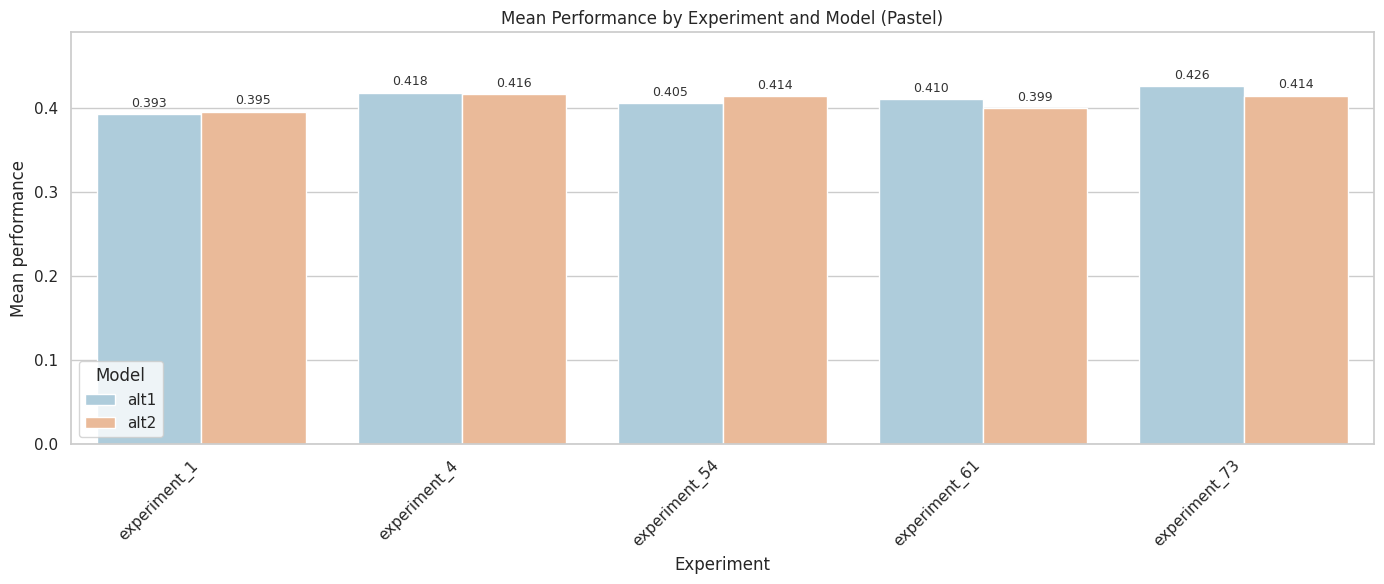

In [19]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["alt1", "alt2"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "alt1": "#a6cee3",  # pastel blue
    "alt2": "#F8B88B",  # pastel orange
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()